# Chronos-2 Quality Net — Results, prediction_length=4, context_length=256 (2026-08-18)

`train/finetune_chronos2.py --prediction-length 4 --context-length 256`, `eval/backtest.py
--context-length 256`로 실행한 결과입니다. prediction_length=4는 `results_context512.ipynb`에서
1보다 낫다고 확인되어 이후 실험의 기본값으로 고정했고, 이번엔 **context_length만 512(기존 기본값) →
256으로 바꿨습니다**. `results_context512.ipynb`(prediction_length=4, context_length=512),
`results_context128.ipynb`/`results_context168.ipynb`/`results_context73.ipynb`(다른 context_length
값들)와 나란히 열어서 비교하면 됩니다.

context_length는 파인튜닝 여부와 무관하게 추론 시 모델에 들어가는 입력 길이 자체를 바꾸는 값이라,
**zero-shot도 `--context-length 256`으로 새로 평가했습니다** (반면 prediction_length은 학습 시
held-out 구간 길이라 zero-shot과는 무관합니다).

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*_predlen4_ctx256_*.csv` 결과 파일만 읽습니다.
`eval/backtest.py`의 `predict_df` 호출은 여전히 `prediction_length=1`로 하드코딩되어 있어(평가 방식은
`results_context512.ipynb`와 동일), 학습 시 held-out 구간(4)과 평가 시 예측 구간(1)이 다른 것은
의도된 설계입니다 — 자세한 이유는 `results_context512.ipynb` 및 `EXPERIMENT_LOG.md` 참고.

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음, `--context-length 256`으로 평가
- **LoRA**: `--prediction-length 4 --context-length 256`로 학습 (`checkpoints/{target}_predlen4_ctx256/final`)
- **Full fine-tuning**: `--prediction-length 4 --context-length 256`, `learning_rate=1e-6`
  (`checkpoints/{target}_full_predlen4_ctx256/final`)

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

METHOD_TAGS = {
    "zero-shot": "predlen4_ctx256_zeroshot",
    "LoRA": "predlen4_ctx256_lora",
    "Full fine-tuning": "predlen4_ctx256_full",
}
METHODS = list(METHOD_TAGS.keys())

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
for target in TARGETS:
    results[target] = {}
    for method, tag in METHOD_TAGS.items():
        p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         67.7133  92.9699  0.3904         0.6892  1007   
        LoRA              67.6058  92.8106  0.3925         0.6912  1007   
        Full fine-tuning  65.9576  90.7871  0.4187         0.7100  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4465   0.6211  0.8086         0.7937   979   
        LoRA               0.4437   0.6143  0.8128         0.7957   979   
        Full fine-tuning   0.4462   0.6117  0.8144         0.7957   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.4359  
        LoRA                         0.4379  
        Full fine-tuning             0.4955  
residue naive                           NaN  
        zero-shot                    0.4178  
        LoRA                         0.4494  
        Full fine-tuning             0.4709

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

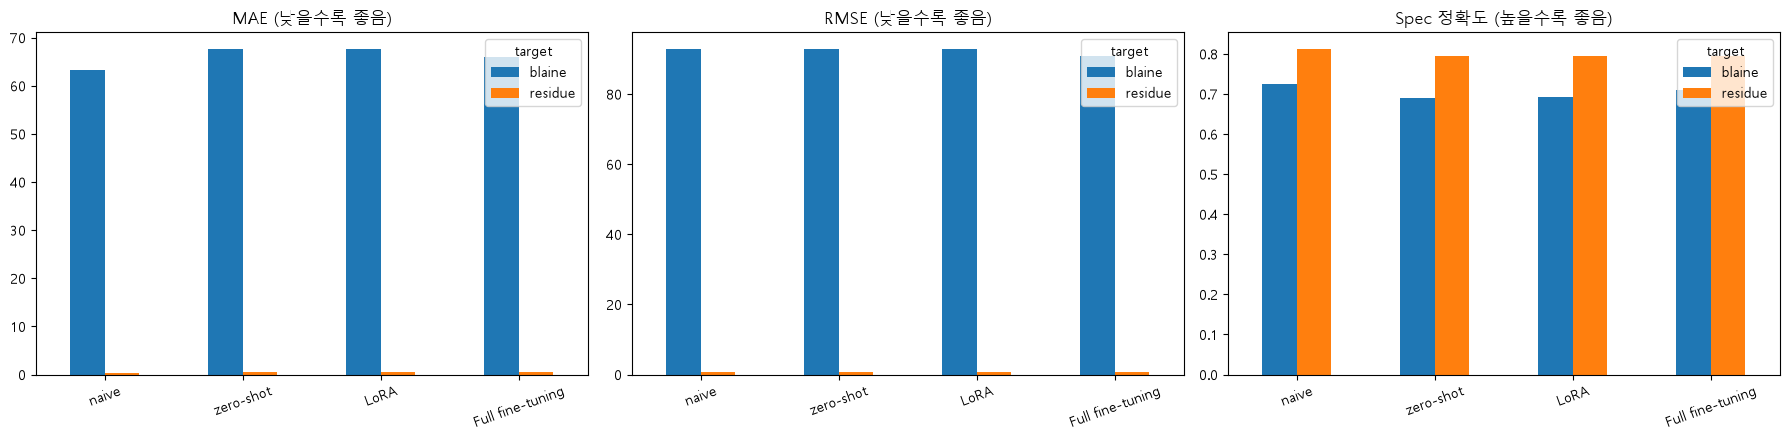

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

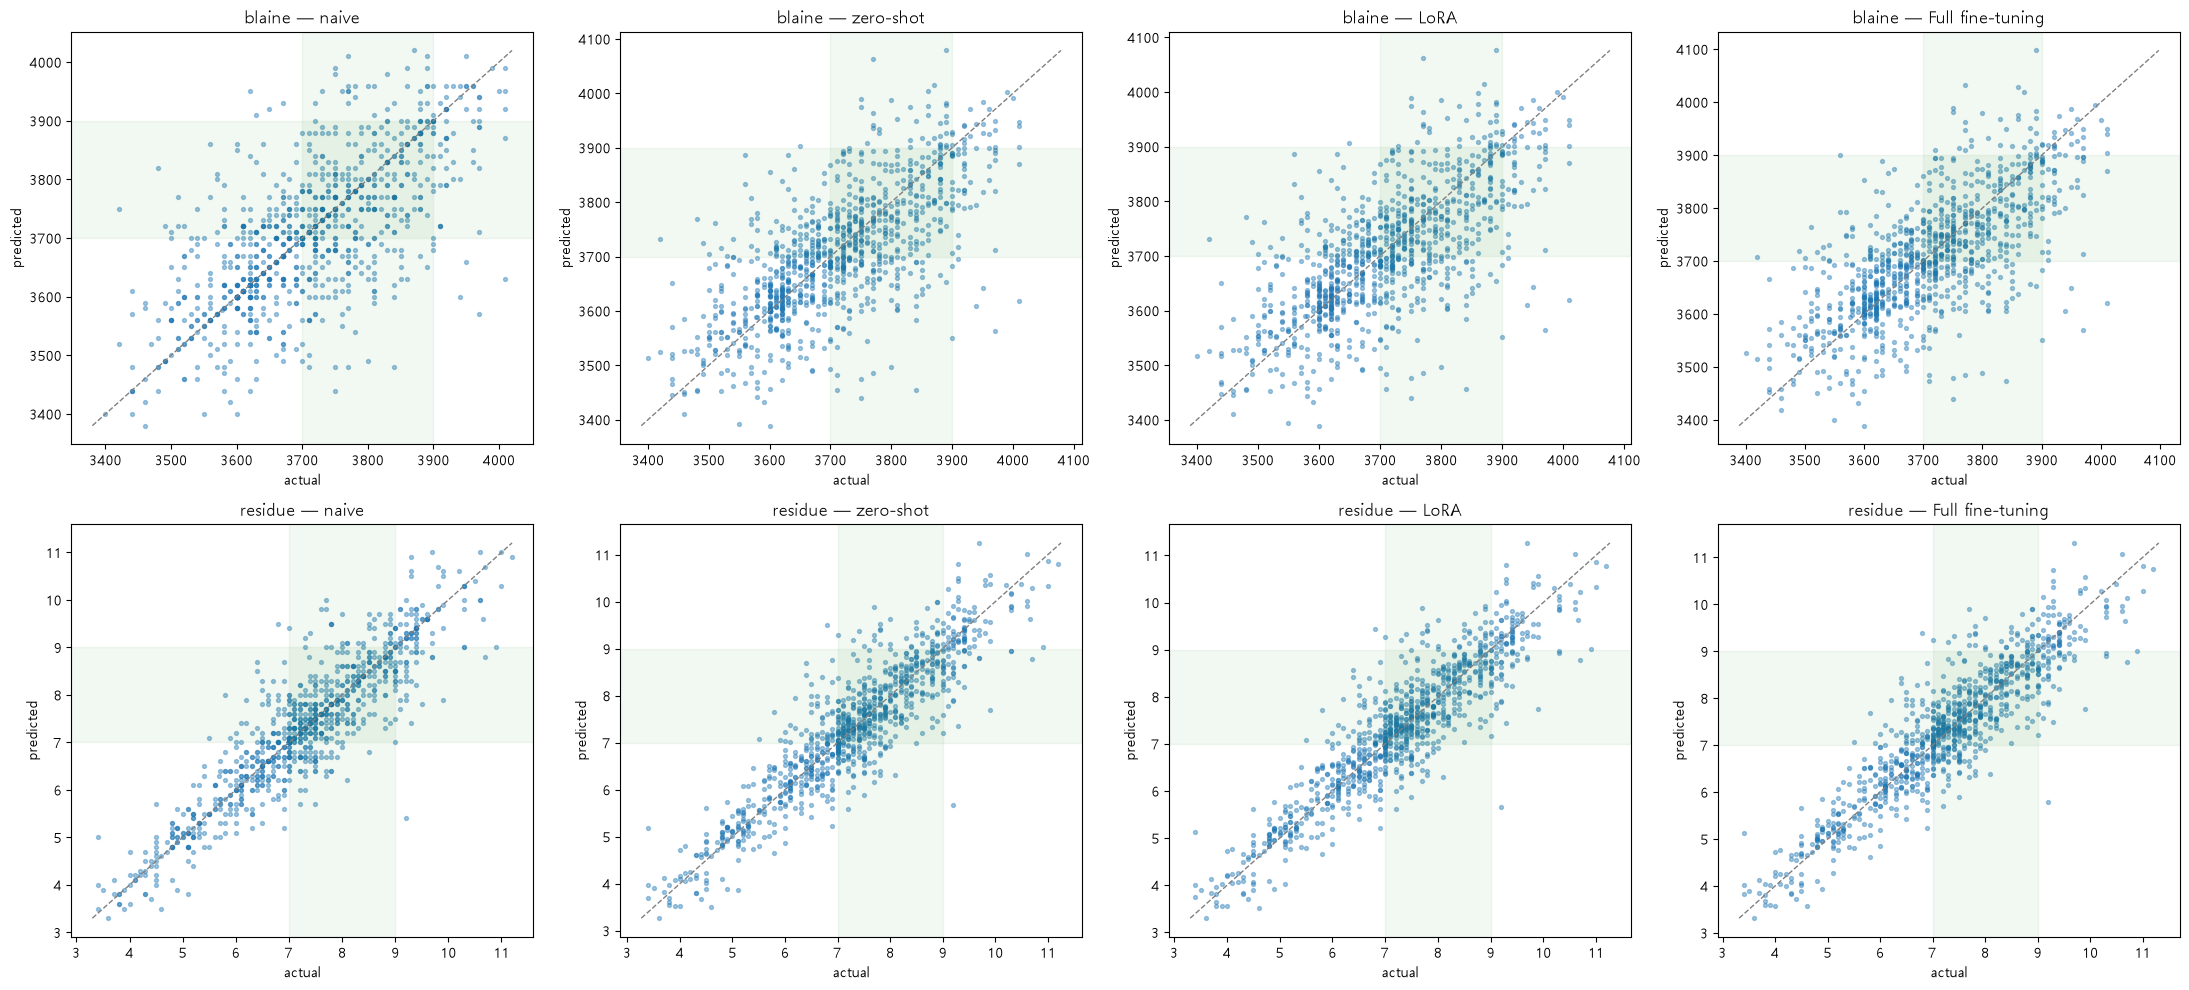

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

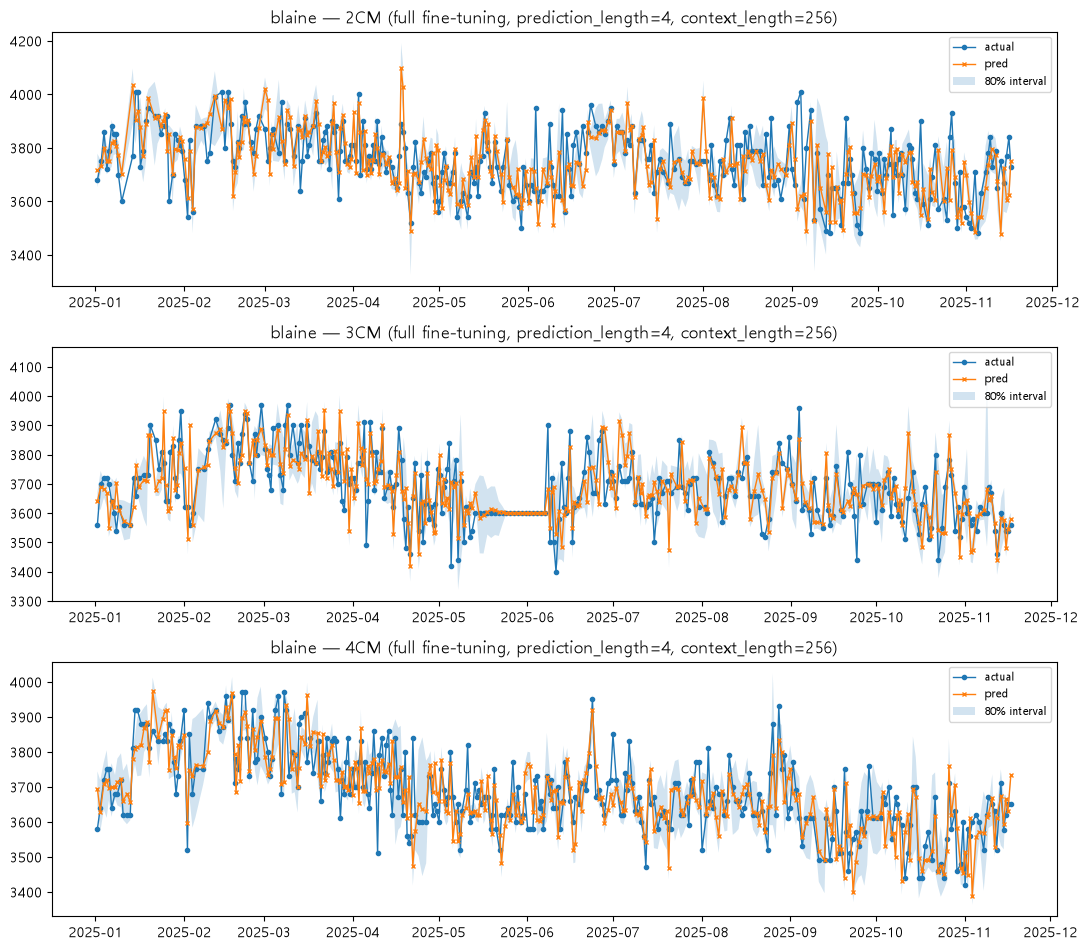

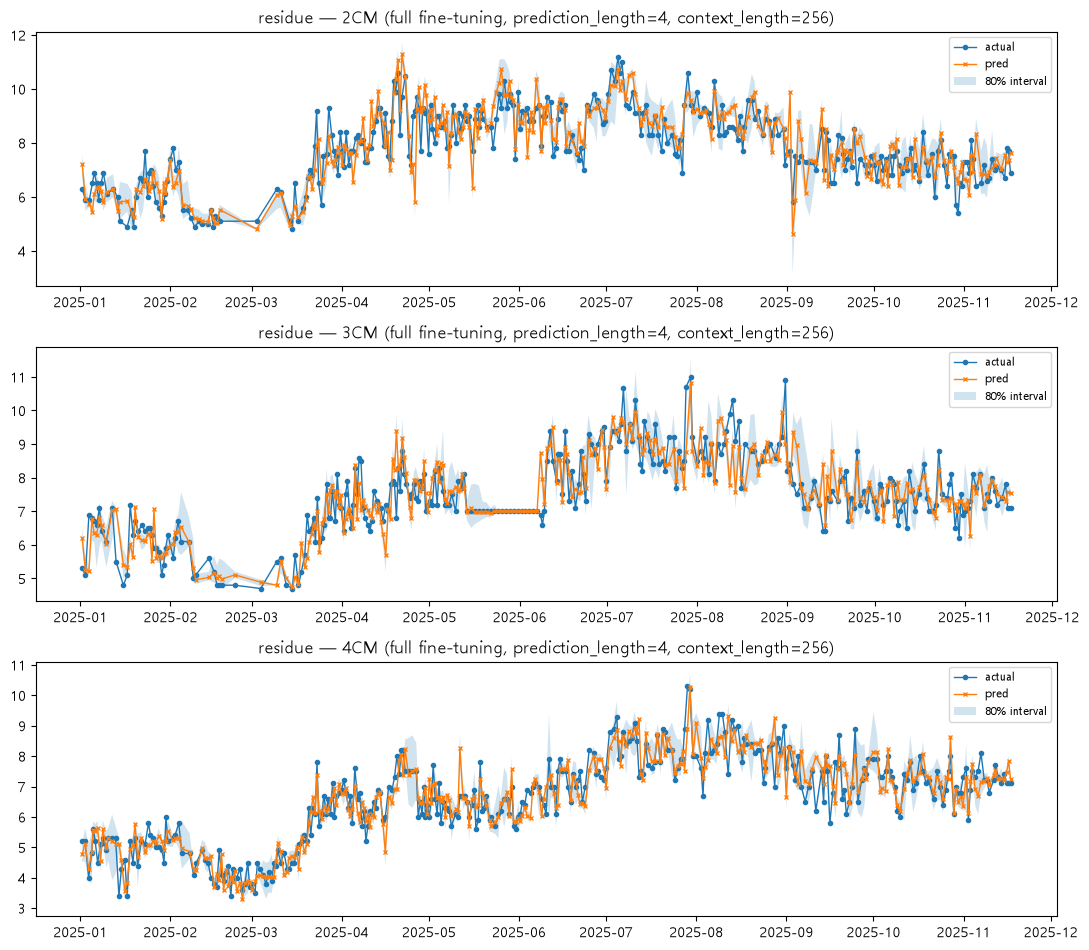

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, prediction_length=4, context_length=256)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

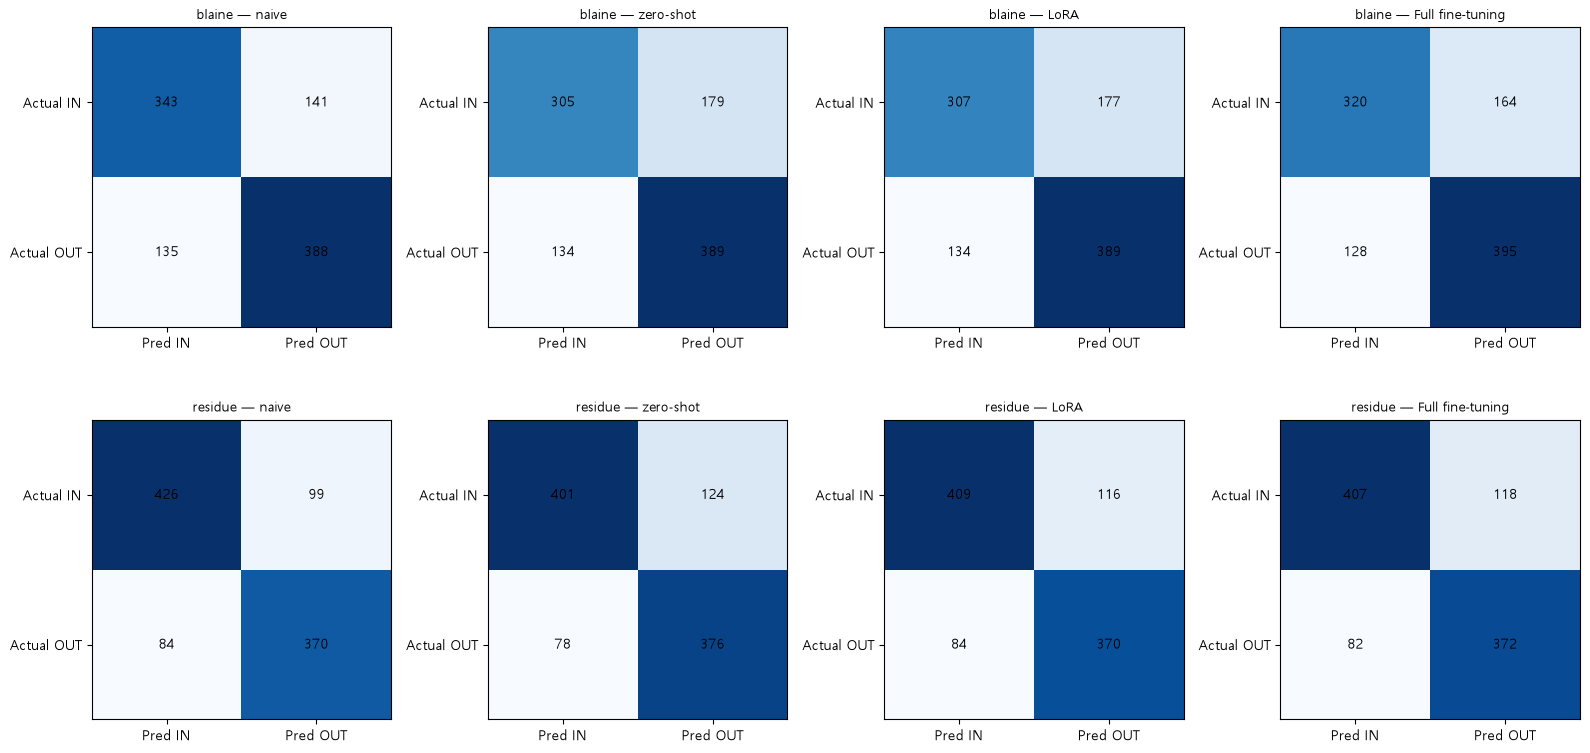

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

- **context_length를 512(prediction_length=4 기준)에서 256으로 줄이니, 6개 조합(2타깃×3방식) 전부에서
  MAE·R²·spec 정확도가 나빠졌습니다.** blaine Full 기준 MAE 64.18(ctx512) → 65.96(ctx256), R² 0.4550 →
  0.4187. residue Full도 MAE 0.4298 → 0.4462, R² 0.8295 → 0.8144로 악화됐습니다. `results_context128.ipynb`/
  `results_context168.ipynb`/`results_context73.ipynb`에서 이미 확인된 "context 축소 = 손해" 패턴이
  256에서도 반복됩니다.
- **80% 예측구간 커버리지는 대체로 개선**됐습니다 (blaine: zero-shot 41.01%→43.59%, LoRA 42.80%→43.79%,
  Full 48.36%→49.55%; residue: zero-shot 39.63%→41.78%, LoRA 43.92%→44.94%) — 다만 **residue Full만
  예외적으로 하락**했습니다(51.17%→47.09%).
- **다른 context_length 값들과 비교하면 256은 중간 정도 성능**입니다. blaine Full MAE 기준
  ctx512(64.18) < ctx168(65.89) < **ctx256(65.96)** < ctx73(66.66) < ctx128(68.51)로, context_length와
  성능이 깔끔하게 비례하지는 않습니다(ctx128이 ctx73보다 오히려 더 나쁨 등) — 지금까지 테스트한 값 중에는
  512가 여전히 가장 좋습니다.
- 종합하면 **context_length=512를 유지하는 게 맞다**는 기존 결론이 256에서도 다시 확인됐습니다.

다른 context_length 결과는 `results_context512.ipynb`(최고 성능), `results_context168.ipynb`,
`results_context128.ipynb`, `results_context73.ipynb`, `results_context24.ipynb`(prediction_length=1
기준) 참고.